# Bao cao mo hinh LSTM du doan tin hieu co phieu

## 1. Gioi thieu

Notebook nay trinh bay qua trinh xay dung va danh gia mo hinh Long Short-Term Memory (LSTM) cho du lieu co phieu theo ngay. Mo hinh khong du doan gia tuyet doi ma phan loai loi suat trong 5 phien tiep theo thanh ba tin hieu:

- `SELL`: future return <= -2.5%
- `HOLD`: -2.5% < future return < 2.5%
- `BUY`: future return >= 2.5%

Day la phien ban cai tien bo sung cho he thong Model 3. Muc tieu la kiem tra xem mo hinh hoc sau co the khai thac chuoi dien bien 30 phien de tao ra tin hieu tot hon mo hinh Machine Learning tren du lieu bang hay khong.

## 2. Muc tieu

1. Tao chuoi du lieu theo tung ma co phieu, khong noi tiep cac ma khac nhau.
2. Chuan hoa feature ma khong de ro ri thong tin tu tap validation/test.
3. Huan luyen LSTM classifier ba lop SELL/HOLD/BUY.
4. Danh gia bang Accuracy, Macro Precision, Macro Recall, Macro F1, confusion matrix va precision cua tin hieu.
5. Luu model, scaler, prediction va cac bao cao CSV de so sanh voi Model 3.

> Quy uoc: moi cell Markdown giai thich muc dich cua buoc tiep theo; moi cell Python thuc thi buoc do.

In [1]:
# Chi chay cell nay tren Google Colab.
# Neu chay local VS Code, bo qua cell nay.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Khong phai Google Colab; bo qua mount Google Drive.')

Mounted at /content/drive


## 3. Moi truong chay va du lieu dau vao

Cell Python ben duoi ket noi Google Drive khi chay tren Colab. GPU khong bat buoc voi mo hinh LSTM nho, nhung GPU T4 giup rut ngan thoi gian huan luyen. Du lieu dau vao la `features_all.csv`, duoc tao tu pipeline lam sach va feature engineering cua du an.

In [2]:
%pip -q install tensorflow scikit-learn pandas matplotlib joblib

import json
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


### 3.1 Khoi tao thu vien va tinh lap

Cell nay cai dat TensorFlow va cac thu vien phu tro. Seed duoc co dinh de ket qua giua cac lan chay co tinh lap cao hon, du khong dam bao hoan toan giong nhau tren moi phan cung GPU.

## Cau hinh du lieu

Tren Colab, dat file `features_all.csv` trong Google Drive va sua `DATA_PATH` neu can. Neu upload thu cong, co the dung `files.upload()` thay cho Google Drive.

## 4. Co so ly thuyet cua LSTM

LSTM la mot bien the cua Recurrent Neural Network (RNN), duoc thiet ke de hoc quan he phu thuoc dai trong chuoi thoi gian. RNN co the bi mat thong tin khi chuoi dai do van de gradient vanishing hoac exploding. LSTM giai quyet van de nay bang mot cell state va ba cong dieu khien.

Voi dau vao $x_t$, hidden state truoc do $h_{t-1}$ va cell state $c_{t-1}$, cac cong co dang:

$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

$$
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i), \qquad
\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

$$
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o), \qquad
h_t = o_t \odot \tanh(c_t)
$$

Trong do:

- **Forget gate** $f_t$ quyet dinh thong tin cu nao can quen.
- **Input gate** $i_t$ quyet dinh thong tin moi nao can ghi vao bo nho.
- **Cell state** $c_t$ luu thong tin quan trong qua nhieu buoc thoi gian.
- **Output gate** $o_t$ tao hidden state dung cho buoc tiep theo.
- $\sigma$ la ham sigmoid, $\tanh$ la ham kich hoat hyperbolic tangent.

Trong bai toan nay, moi mau dau vao co dang `(30 phien, so feature)`. LSTM doc lan luot 30 phien gan nhat cua mot ma co phieu, sau do lop Dense softmax tra ve xac suat cua ba lop SELL, HOLD va BUY.

In [3]:
RUNNING_IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False

# Sua duong dan nay neu file nam o vi tri khac trong Google Drive.
if RUNNING_IN_COLAB:
    DATA_PATH = Path('/content/drive/MyDrive/features_all.csv')
else:
    DATA_PATH = Path('data/clean/features_all.csv')

OUTPUT_DIR = Path('lstm_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEQ_LEN = 30
HORIZON = 5
TRAIN_END = '2024-01-01'
VALIDATION_END = '2025-01-01'
MAX_SEQUENCES = {'train': 180_000, 'validation': 60_000, 'test': 80_000}

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Khong tim thay {DATA_PATH}. Hay sua DATA_PATH o cell nay.'
    )

print('DATA_PATH:', DATA_PATH.resolve())
print('Output:', OUTPUT_DIR.resolve())

DATA_PATH: /content/drive/MyDrive/features_all.csv
Output: /content/lstm_outputs


### 4.1 Cau hinh thuc nghiem

- `SEQ_LEN = 30`: moi mau gom 30 phien gan nhat.
- `HORIZON = 5`: nhan duoc tinh bang loi suat sau 5 phien.
- Tap train ket thuc truoc `2024-01-01`.
- Tap validation nam trong giai doan tu `2024-01-01` den truoc `2025-01-01`.
- Tap test bat dau tu `2025-01-01`.
- `MAX_SEQUENCES` gioi han so mau de Colab khong bi qua tai RAM.

Day la cach chia theo thoi gian, phu hop voi du lieu tai chinh va tranh dung du lieu tuong lai de du doan qua khu.

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else 'Khong co GPU, se chay bang CPU')

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [str(c).strip().lower() for c in df.columns]
df['trading_date'] = pd.to_datetime(
    df['trading_date'], errors='coerce'
)
df['symbol'] = df['symbol'].astype(str).str.strip().str.upper()
df = (
    df.sort_values(['symbol', 'trading_date'])
    .drop_duplicates(['symbol', 'trading_date'])
    .dropna(subset=['symbol', 'trading_date', 'close'])
)

# Chuyen gia va thanh khoan sang dang tuong doi de LSTM hoc duoc nhieu ma.
for column in ['open', 'high', 'low', 'close', 'volume']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df['open_rel'] = df['open'] / df['close'] - 1.0
df['high_rel'] = df['high'] / df['close'] - 1.0
df['low_rel'] = df['low'] / df['close'] - 1.0
df['close_rel'] = 0.0
df['log_volume'] = np.log1p(df['volume'].clip(lower=0))

# Bo gia/MA tuyet doi; giu indicator va return giong Model 3.
FEATURES = [
    'open_rel', 'high_rel', 'low_rel', 'close_rel', 'log_volume',
    'return_1d', 'return_3d', 'return_5d', 'return_10d', 'return_20d',
    'price_vs_ma20', 'ma5_vs_ma20',
    'volume_ratio_5_20', 'volume_change_1d',
    'volatility_5d', 'volatility_20d', 'volatility_change',
    'drawdown_20d', 'daily_range', 'body_ratio', 'close_position',
]

FEATURES = [column for column in FEATURES if column in df.columns]
for column in FEATURES:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df['future_close'] = df.groupby('symbol')['close'].shift(-HORIZON)
df['future_return_5d'] = df['future_close'] / df['close'] - 1.0

df['target_signal_label'] = np.select(
    [
        df['future_return_5d'] <= -0.025,
        df['future_return_5d'] >= 0.025,
    ],
    [0, 2],
    default=1,
)
df['target_signal'] = df['target_signal_label'].map(
    {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
)

df = df[df['future_return_5d'].abs() <= 0.20].copy()
df = (
    df.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=FEATURES + ['future_return_5d'])
    .reset_index(drop=True)
)

print('Rows:', len(df))
print('Symbols:', df['symbol'].nunique())
print('Features:', FEATURES)
print(df['target_signal'].value_counts())

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Rows: 663264
Symbols: 472
Features: ['open', 'high', 'low', 'close', 'volume', 'return_1d', 'return_3d', 'return_5d', 'return_10d', 'return_20d', 'ma_5', 'ma_20', 'ma_50', 'price_vs_ma20', 'ma5_vs_ma20', 'volume_ma_5', 'volume_ma_20', 'volume_ratio_5_20', 'volume_change_1d', 'volatility_5d', 'volatility_20d', 'volatility_change', 'rolling_max_20d', 'drawdown_20d', 'daily_range', 'body_ratio', 'close_position']
target_signal
HOLD    296222
SELL    187760
BUY     179282
Name: count, dtype: int64


## 5. Tien xu ly va feature engineering

Cell Python ben duoi lam sach khoa chinh `(symbol, trading_date)`, chuyen kieu du lieu va tao nhan tu gia dong cua tuong lai. Gia va thanh khoan tuyet doi duoc chuyen sang dang tuong doi:

- `open_rel`, `high_rel`, `low_rel`: quan he cua OHLC voi gia dong cua hien tai.
- `log_volume`: logarit hoa thanh khoan de giam anh huong cua outlier.
- Cac return, volatility, drawdown va chi bao ky thuat duoc tai su dung tu `features_all`.

Cach bieu dien nay giup mo hinh hoc mau hinh bien dong giua nhieu ma co phieu co muc gia khac nhau.

## Split theo thoi gian va scale
Scaler chi duoc fit tren cac dong train. Sequence duoc tao rieng cho tung symbol, sau do gan theo ngay cua target; vi vay khong co sequence noi hai ma khac nhau.

In [5]:
train_end = pd.Timestamp(TRAIN_END)
validation_end = pd.Timestamp(VALIDATION_END)

train_rows = df["trading_date"] < train_end
validation_rows = (
    (df["trading_date"] >= train_end)
    & (df["trading_date"] < validation_end)
)
test_rows = df["trading_date"] >= validation_end

scaler = RobustScaler()
scaler.fit(df.loc[train_rows, FEATURES])

df_scaled = df.copy()
df_scaled[FEATURES] = scaler.transform(
    df_scaled[FEATURES]
).astype("float32")

joblib.dump(scaler, OUTPUT_DIR / "scaler.joblib")

print("Train rows:", train_rows.sum())
print("Validation rows:", validation_rows.sum())
print("Test rows:", test_rows.sum())

Train rows: 483151
Validation rows: 74979
Test rows: 105134


## 6. Chia du lieu va chuan hoa

Scaler duoc fit duy nhat tren tap train, sau do ap dung cho validation va test. Dieu nay ngan chan data leakage. `RobustScaler` duoc chon vi du lieu gia va volume co the co outlier manh.

In [6]:
def make_sequences(
    frame,
    feature_columns,
    sequence_length,
    split_masks,
    max_sequences,
):
    sequences = {name: [] for name in split_masks}
    labels = {name: [] for name in split_masks}
    returns = {name: [] for name in split_masks}
    dates = {name: [] for name in split_masks}
    symbols = {name: [] for name in split_masks}

    for symbol, group in frame.groupby("symbol", sort=False):
        group = group.sort_values("trading_date")

        values = group[feature_columns].to_numpy(
            dtype="float32"
        )
        target_labels = group[
            "target_signal_label"
        ].to_numpy(dtype="int32")
        target_returns = group[
            "future_return_5d"
        ].to_numpy(dtype="float32")
        target_dates = group[
            "trading_date"
        ].to_numpy()

        for end in range(sequence_length - 1, len(group)):
            target_date = pd.Timestamp(target_dates[end])

            split_name = next(
                (
                    name
                    for name, mask in split_masks.items()
                    if mask(target_date)
                ),
                None,
            )

            if split_name is None:
                continue

            if (
                len(sequences[split_name])
                >= max_sequences[split_name]
            ):
                continue

            sequences[split_name].append(
                values[
                    end - sequence_length + 1 : end + 1
                ]
            )
            labels[split_name].append(
                target_labels[end]
            )
            returns[split_name].append(
                target_returns[end]
            )
            dates[split_name].append(target_date)
            symbols[split_name].append(symbol)

    result = {}

    for name in split_masks:
        result[name] = {
            "X": np.asarray(
                sequences[name],
                dtype="float32",
            ),
            "y": np.asarray(
                labels[name],
                dtype="int32",
            ),
            "returns": np.asarray(
                returns[name],
                dtype="float32",
            ),
            "dates": pd.to_datetime(dates[name]),
            "symbols": np.asarray(symbols[name]),
        }

        print(
            name,
            result[name]["X"].shape,
            result[name]["y"].shape,
        )

    return result


split_masks = {
    "train": lambda date: date < train_end,
    "validation": lambda date: (
        train_end <= date < validation_end
    ),
    "test": lambda date: date >= validation_end,
}

data = make_sequences(
    df_scaled,
    FEATURES,
    SEQ_LEN,
    split_masks,
    MAX_SEQUENCES,
)

X_train = data["train"]["X"]
y_train = data["train"]["y"]

X_val = data["validation"]["X"]
y_val = data["validation"]["y"]

X_test = data["test"]["X"]
y_test = data["test"]["y"]

test_returns = data["test"]["returns"]
test_dates = data["test"]["dates"]
test_symbols = data["test"]["symbols"]

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError(
        "Mot trong cac tap khong co sequence."
    )

print("Train label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

train (180000, 30, 27) (180000,)
validation (60000, 30, 27) (60000,)
test (80000, 30, 27) (80000,)
Train label distribution:
0    51677
1    77528
2    50795
Name: count, dtype: int64


## 7. Tao chuoi du lieu cho LSTM

Cell nay tao sequence theo tung `symbol`. Voi moi ngay $t$, dau vao la 30 phien tu $t-29$ den $t$, con target la nhan future return tai $t+5$. Viec group theo ma truoc khi tao sequence la bat buoc; neu noi toan bo CSV lien tuc, sequence co the chuyen tu ma nay sang ma khac va lam sai y nghia thoi gian.

In [ ]:
tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQ_LEN, len(FEATURES))),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(3, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        23,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,547 (142.76 KB)

 Trainable params: 36,547 (142.76 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Kien truc mo hinh

Mo hinh gom hai lop LSTM xep chong, Dropout de giam overfitting, Dense trung gian va lop softmax 3 lop:

```text
Input (30 phien, so feature)
    -> LSTM(64, return_sequences=True)
    -> Dropout(0.25)
    -> LSTM(32)
    -> Dense(32, ReLU)
    -> Dropout(0.15)
    -> Dense(3, Softmax)
```

Lop softmax tra ve ba xac suat co tong bang 1. Nhan co xac suat lon nhat la tin hieu raw. Sau do confidence threshold duoc toi uu tren validation de tao tin hieu adjusted.

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        OUTPUT_DIR / 'best_lstm_classifier.keras',
        monitor='val_loss',
        save_best_only=True,
    ),
]

# Khong dung class_weight: muc tieu la giu precision BUY/SELL, tranh tao qua nhieu tin hieu gia.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)

model.save(OUTPUT_DIR / 'model_lstm_model3_style.keras')

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4577 - loss: 1.0476 - val_accuracy: 0.5263 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4767 - loss: 1.0291 - val_accuracy: 0.5268 - val_loss: 0.9810 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4822 - loss: 1.0227 - val_accuracy: 0.5340 - val_loss: 0.9774 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4881 - loss: 1.0161 - val_accuracy: 0.5315 - val_loss: 0.9763 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4927 - loss: 1.0092 - val_accuracy: 0.5252 - val_loss: 0.9834 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4989 - loss: 1.0013 - val_accuracy: 0.5219 - val_loss: 0.9863 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5053 - loss: 0

## 9. Huan luyen

Mo hinh su dung Adam voi learning rate `3e-4` va loss `sparse_categorical_crossentropy`. Khong su dung `class_weight` trong phien ban nay vi muc tieu la khong tao qua nhieu tin hieu BUY/SELL gia, tu do uu tien precision. EarlyStopping dung `val_loss` de giu lai trong so tot nhat; ReduceLROnPlateau giam learning rate khi validation khong con cai thien; ModelCheckpoint luu model tot nhat.

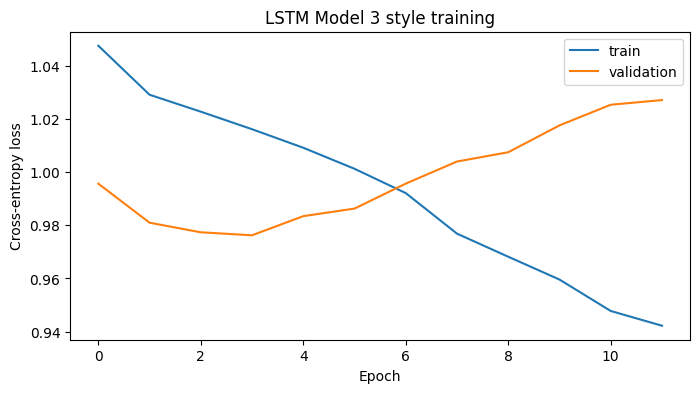

{
  "Accuracy": 51.996249999999996,
  "Macro_Precision": 0.47277454654594736,
  "Macro_Recall": 0.4710404886025821,
  "Macro_F1": 0.46630292829942427,
  "Adjusted_Accuracy": 54.0025,
  "Adjusted_Macro_Precision": 0.5762147815828678,
  "Adjusted_Macro_Recall": 0.37466175987179245,
  "Adjusted_Macro_F1": 0.3188007998853171,
  "Baseline_Accuracy": 51.688750000000006,
  "Baseline_Label": "HOLD",
  "Confusion_Matrix": [
    [
      9796,
      6871,
      3135
    ],
    [
      9636,
      26628,
      5087
    ],
    [
      6264,
      7410,
      5173
    ]
  ],
  "Adjusted_Confusion_Matrix": [
    [
      1754,
      17725,
      323
    ],
    [
      631,
      40303,
      417
    ],
    [
      615,
      17087,
      1145
    ]
  ]
}


,trading_date,symbol,actual_future_return_5d,target_signal_label,target_signal,predicted_signal_label,predicted_signal,adjusted_signal_label,adjusted_signal,sell_probability,hold_probability,buy_probability,predicted_signal_score
0,2025-01-02,ABR,-0.018536,1,HOLD,0,SELL,0,SELL,0.629200,0.223225,0.147575,-0.481625
1,2025-01-08,ABR,0.018674,1,HOLD,0,SELL,0,SELL,0.602776,0.254076,0.143148,-0.459628
2,2025-01-10,ABR,0.034123,2,BUY,0,SELL,1,HOLD,0.545690,0.300082,0.154228,-0.391463
3,2025-01-14,ABR,0.026540,2,BUY,0,SELL,1,HOLD,0.463288,0.359958,0.176754,-0.286535
4,2025-01-17,ABR,-0.046746,0,SELL,0,SELL,0,SELL,0.667484,0.191906,0.140609,-0.526875


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('LSTM Model 3 style training')
plt.legend()
plt.show()

label_names = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}

# Chon nguong confidence tren validation, khong dung test de toi uu threshold.
def make_adjusted_labels(probabilities, confidence_threshold):
    sell_probability = probabilities[:, 0]
    hold_probability = probabilities[:, 1]
    buy_probability = probabilities[:, 2]
    score = buy_probability - sell_probability

    labels = np.ones(len(probabilities), dtype='int32')
    buy_mask = (
        (buy_probability >= confidence_threshold)
        & (buy_probability >= hold_probability)
        & (score >= 0.0)
    )
    sell_mask = (
        (sell_probability >= confidence_threshold)
        & (sell_probability >= hold_probability)
        & (-score >= 0.0)
    )
    labels[buy_mask] = 2
    labels[sell_mask] = 0
    return labels

validation_probabilities = model.predict(
    X_val,
    batch_size=1024,
    verbose=0,
)
threshold_rows = []
for threshold in np.arange(0.50, 0.76, 0.01):
    validation_adjusted = make_adjusted_labels(
        validation_probabilities,
        float(threshold),
    )
    _, _, validation_f1, _ = precision_recall_fscore_support(
        y_val,
        validation_adjusted,
        labels=[0, 1, 2],
        average='macro',
        zero_division=0,
    )
    threshold_rows.append({
        'confidence_threshold': round(float(threshold), 2),
        'validation_macro_f1': float(validation_f1),
        'validation_signal_count': int((validation_adjusted != 1).sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values(
    ['validation_macro_f1', 'confidence_threshold'],
    ascending=[False, True],
).iloc[0]
selected_confidence_threshold = float(
    best_threshold_row['confidence_threshold']
)
threshold_df.to_csv(
    OUTPUT_DIR / 'confidence_threshold_validation.csv',
    index=False,
    encoding='utf-8-sig',
)
print('Selected confidence threshold:', selected_confidence_threshold)

probabilities = model.predict(
    X_test,
    batch_size=1024,
    verbose=0,
)
predicted_labels = probabilities.argmax(axis=1)
adjusted_labels = make_adjusted_labels(
    probabilities,
    selected_confidence_threshold,
)

predicted_signals = np.array([
    label_names[label] for label in predicted_labels
])
sell_probability = probabilities[:, 0]
hold_probability = probabilities[:, 1]
buy_probability = probabilities[:, 2]
predicted_signal_score = buy_probability - sell_probability

accuracy = accuracy_score(y_test, predicted_labels) * 100
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    predicted_labels,
    labels=[0, 1, 2],
    average='macro',
    zero_division=0,
)
adjusted_accuracy = accuracy_score(y_test, adjusted_labels) * 100
adjusted_precision, adjusted_recall, adjusted_f1, _ = precision_recall_fscore_support(
    y_test,
    adjusted_labels,
    labels=[0, 1, 2],
    average='macro',
    zero_division=0,
)

baseline_label = int(pd.Series(y_test).mode().iloc[0])
baseline_accuracy = accuracy_score(
    y_test,
    np.full(len(y_test), baseline_label),
) * 100

metrics = {
    'Accuracy': float(accuracy),
    'Macro_Precision': float(precision),
    'Macro_Recall': float(recall),
    'Macro_F1': float(f1),
    'Adjusted_Accuracy': float(adjusted_accuracy),
    'Adjusted_Macro_Precision': float(adjusted_precision),
    'Adjusted_Macro_Recall': float(adjusted_recall),
    'Adjusted_Macro_F1': float(adjusted_f1),
    'Baseline_Accuracy': float(baseline_accuracy),
    'Baseline_Label': label_names[baseline_label],
    'Selected_Confidence_Threshold': selected_confidence_threshold,
    'Confusion_Matrix': confusion_matrix(
        y_test, predicted_labels, labels=[0, 1, 2]
    ).tolist(),
    'Adjusted_Confusion_Matrix': confusion_matrix(
        y_test, adjusted_labels, labels=[0, 1, 2]
    ).tolist(),
}

print(json.dumps(metrics, indent=2))
with open(OUTPUT_DIR / 'metrics.json', 'w', encoding='utf-8') as file:
    json.dump(metrics, file, indent=2)

predictions = pd.DataFrame({
    'trading_date': test_dates,
    'symbol': test_symbols,
    'actual_future_return_5d': test_returns,
    'target_signal_label': y_test,
    'target_signal': [label_names[label] for label in y_test],
    'predicted_signal_label': predicted_labels,
    'predicted_signal': predicted_signals,
    'adjusted_signal_label': adjusted_labels,
    'adjusted_signal': [label_names[label] for label in adjusted_labels],
    'sell_probability': sell_probability,
    'hold_probability': hold_probability,
    'buy_probability': buy_probability,
    'predicted_signal_score': predicted_signal_score,
})
predictions.to_csv(OUTPUT_DIR / 'predictions.csv', index=False)
predictions.head()

## 10. Danh gia mo hinh

Cell nay du doan tren tap test va tao hai loai ket qua:

- **Raw signal**: lop co xac suat cao nhat trong ba lop.
- **Adjusted signal**: BUY/SELL chi duoc kich hoat khi xac suat vuot confidence threshold va cao hon HOLD.

Confidence threshold duoc chon tren validation bang Macro F1, sau do chi ap dung mot lan cho test. Cach nay tranh toi uu truc tiep tren tap test. Ngoai metric classification, notebook luu prediction theo symbol/ngay de phuc vu backtest va dashboard.

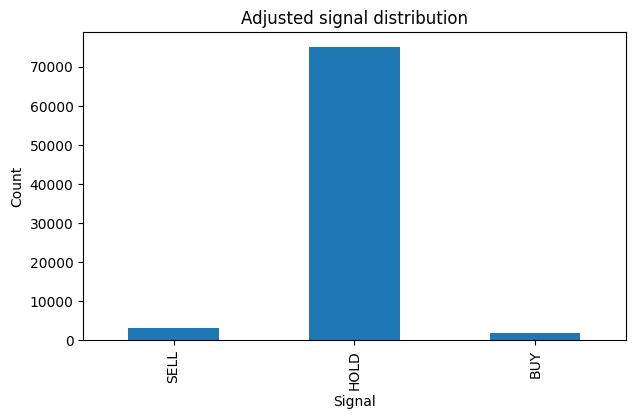

Da luu:
lstm_outputs/best_lstm_classifier.keras
lstm_outputs/metrics.json
lstm_outputs/model_lstm_model3_style.keras
lstm_outputs/predictions.csv
lstm_outputs/scaler.joblib


In [10]:
signal_counts = predictions['adjusted_signal'].value_counts()
signal_counts.reindex(['SELL', 'HOLD', 'BUY'], fill_value=0).plot(
    kind='bar',
    figsize=(7, 4),
    title='Adjusted signal distribution',
)
plt.xlabel('Signal')
plt.ylabel('Count')
plt.show()

print('Da luu:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path)

## 11. Phan bo tin hieu va san pham dau ra

Cell nay kiem tra so luong SELL/HOLD/BUY sau confidence filter. Cac file duoc tao trong `lstm_outputs/` gom:

- `model_lstm_model3_style.keras`: mo hinh LSTM da huan luyen.
- `best_lstm_classifier.keras`: checkpoint co `val_loss` tot nhat.
- `scaler.joblib`: RobustScaler da fit tren tap train.
- `predictions.csv`: du doan theo symbol va ngay.
- `metrics.json`, `metrics_summary.csv`: metric tong hop.
- `metrics_by_class.csv`: precision, recall, F1 theo SELL/HOLD/BUY.
- `confusion_matrix.csv`: ma tran nham lan.
- `backtest_metrics.csv`: ket qua backtest don gian.
- `confidence_threshold_validation.csv`: ket qua chon threshold tren validation.

In [ ]:
from sklearn.metrics import classification_report

# Bao cao metric tong hop dang CSV de so sanh voi Model 3.
metric_rows = [
    {'metric_group': 'classification', 'metric': 'accuracy', 'value': accuracy},
    {'metric_group': 'classification', 'metric': 'macro_precision', 'value': precision},
    {'metric_group': 'classification', 'metric': 'macro_recall', 'value': recall},
    {'metric_group': 'classification', 'metric': 'macro_f1', 'value': f1},
    {'metric_group': 'classification', 'metric': 'adjusted_accuracy', 'value': adjusted_accuracy},
    {'metric_group': 'classification', 'metric': 'adjusted_macro_precision', 'value': adjusted_precision},
    {'metric_group': 'classification', 'metric': 'adjusted_macro_recall', 'value': adjusted_recall},
    {'metric_group': 'classification', 'metric': 'adjusted_macro_f1', 'value': adjusted_f1},
    {'metric_group': 'classification', 'metric': 'baseline_accuracy', 'value': baseline_accuracy},
    {'metric_group': 'dataset', 'metric': 'test_rows', 'value': len(y_test)},
    {'metric_group': 'dataset', 'metric': 'test_symbols', 'value': predictions['symbol'].nunique()},
    {'metric_group': 'dataset', 'metric': 'test_start_date', 'value': str(predictions['trading_date'].min())},
    {'metric_group': 'dataset', 'metric': 'test_end_date', 'value': str(predictions['trading_date'].max())},
]

# Precision/recall/F1 cho tung lop SELL, HOLD, BUY.
class_report = classification_report(
    y_test,
    predicted_labels,
    labels=[0, 1, 2],
    target_names=['SELL', 'HOLD', 'BUY'],
    output_dict=True,
    zero_division=0,
)
for class_name in ['SELL', 'HOLD', 'BUY']:
    for metric_name in ['precision', 'recall', 'f1-score', 'support']:
        metric_rows.append({
            'metric_group': f'class_{class_name.lower()}',
            'metric': metric_name,
            'value': class_report[class_name][metric_name],
        })

# Precision cua cac lenh da duoc kich hoat sau confidence filter.
for signal_name, signal_label in [('SELL', 0), ('BUY', 2)]:
    signal_mask = adjusted_labels == signal_label
    precision_value = (
        float((y_test[signal_mask] == signal_label).mean())
        if signal_mask.any() else 0.0
    )
    metric_rows.extend([
        {
            'metric_group': 'adjusted_signal',
            'metric': f'{signal_name.lower()}_signals',
            'value': int(signal_mask.sum()),
        },
        {
            'metric_group': 'adjusted_signal',
            'metric': f'{signal_name.lower()}_precision',
            'value': precision_value,
        },
    ])

metrics_summary_df = pd.DataFrame(metric_rows)
metrics_summary_df.to_csv(
    OUTPUT_DIR / 'metrics_summary.csv',
    index=False,
    encoding='utf-8-sig',
)

metrics_by_class_df = pd.DataFrame(class_report).T.reset_index()
metrics_by_class_df = metrics_by_class_df.rename(columns={'index': 'class'})
metrics_by_class_df.to_csv(
    OUTPUT_DIR / 'metrics_by_class.csv',
    index=False,
    encoding='utf-8-sig',
)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, predicted_labels, labels=[0, 1, 2]),
    index=['actual_SELL', 'actual_HOLD', 'actual_BUY'],
    columns=['predicted_SELL', 'predicted_HOLD', 'predicted_BUY'],
)
confusion_matrix_df.to_csv(
    OUTPUT_DIR / 'confusion_matrix.csv',
    encoding='utf-8-sig',
)

# Backtest don gian: moi ngay chon BUY co score cao nhat, khong tinh phi.
backtest_input = predictions.copy()
backtest_input['selected_buy'] = backtest_input['adjusted_signal'] == 'BUY'
selected_daily = (
    backtest_input[backtest_input['selected_buy']]
    .sort_values(['trading_date', 'predicted_signal_score'], ascending=[True, False])
    .groupby('trading_date', as_index=False)
    .head(1)
)
selected_daily = selected_daily.sort_values('trading_date').copy()
selected_daily['strategy_return'] = selected_daily['actual_future_return_5d']
selected_daily['cumulative_return'] = (
    (1.0 + selected_daily['strategy_return']).cumprod() - 1.0
)

backtest_rows = {
    'test_rows': len(predictions),
    'buy_signal_rows': int(backtest_input['selected_buy'].sum()),
    'trade_days': int(selected_daily['trading_date'].nunique()),
    'hit_rate': float((selected_daily['strategy_return'] > 0).mean()) if len(selected_daily) else 0.0,
    'average_return': float(selected_daily['strategy_return'].mean()) if len(selected_daily) else 0.0,
    'cumulative_return': float(selected_daily['cumulative_return'].iloc[-1]) if len(selected_daily) else 0.0,
    'sharpe_ratio': float(
        selected_daily['strategy_return'].mean()
        / selected_daily['strategy_return'].std()
        * np.sqrt(252)
    ) if len(selected_daily) > 1 and selected_daily['strategy_return'].std() > 0 else 0.0,
}
pd.DataFrame([
    {'metric_group': 'backtest', 'metric': key, 'value': value}
    for key, value in backtest_rows.items()
]).to_csv(
    OUTPUT_DIR / 'backtest_metrics.csv',
    index=False,
    encoding='utf-8-sig',
)

print('Da luu metric CSV:')
for filename in [
    'metrics_summary.csv',
    'metrics_by_class.csv',
    'confusion_matrix.csv',
    'backtest_metrics.csv',
]:
    print(OUTPUT_DIR / filename)

metrics_summary_df

## 12. Bao cao ket qua lan chay gan nhat

Ket qua duoc ghi nhan trong thu muc `metrics_lstm/` sau phien train cai tien:

| Metric | LSTM | Model 3 |
|---|---:|---:|
| Accuracy | 55.23% | 56.30% |
| Macro Precision | 0.4912 | 0.5070 |
| Macro Recall | 0.4647 | 0.4610 |
| Macro F1 | 0.4655 | 0.4598 |
| Adjusted Accuracy | 55.01% | 52.69% |
| Adjusted Macro F1 | 0.3594 | 0.2676 |
| BUY precision sau filter | 58.36% | 67.98% |
| SELL precision sau filter | 55.68% | 65.03% |

Dien giai:

- LSTM gan ngang Model 3 ve Accuracy va cao hon nhe ve Macro F1.
- LSTM co Adjusted Accuracy va Adjusted Macro F1 tot hon, cho thay confidence filter tao phan lop can bang hon.
- Model 3 van co precision BUY/SELL cao hon, phu hop hon neu uu tien tin hieu giao dich it sai.
- Backtest LSTM can duoc chuan hoa cung Top-K, transaction cost, slippage va quy tac khong chong len horizon truoc khi ket luan model nao tot hon.

> Cac con so trong bang la ket qua cua lan chay gan nhat. Khi chay lai voi du lieu hoac seed khac, hay cap nhat bang nay tu `metrics_summary.csv` va bao cao Model 3 tuong ung.

## 13. Ket luan

Notebook da dong goi toan bo quy trinh cua model LSTM thanh mot bao cao mini: tu co so ly thuyet, nap du lieu, tien xu ly, tao chuoi, huan luyen, danh gia den luu artifact.

Theo ket qua lan chay gan nhat, LSTM dat Accuracy 55.23% va Macro F1 0.4655, gan voi Model 3. LSTM co Adjusted Macro F1 cao hon, nhung Model 3 van co precision BUY/SELL cao hon. Vi vay, Model 3 dang phu hop hon neu muc tieu la tao tin hieu giao dich chinh xac; LSTM co gia tri nghien cuu bo sung va co the duoc ket hop trong mo hinh ensemble.

Khong nen so sanh truc tiep cumulative return cua hai model cho den khi backtest dung cung Top-K, transaction cost, slippage va quy tac xu ly horizon 5 phien chong len. Cac ket qua moi sau moi lan train nen duoc cap nhat tu `metrics_summary.csv`, `metrics_by_class.csv` va `backtest_metrics.csv`.